<a href="https://colab.research.google.com/github/santoshs0612/Foundational-Math-in-ML/blob/main/Momentum_based_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Momentum-based gradient descent

In [65]:
import numpy as np
import matplotlib.pyplot as plt

### Loss Function definition(we starting with any random loss function)

In [66]:
def quadratic_loss(x,y):
  return x**2 + 10 + y**2

### Gradient Function

In [67]:
def quadratic_grad(x ,y):
  dx = 2 *x
  dy = 2* y
  return np.array([dx,dy])

### Batch Gradient decent

In [68]:

def batch_grad_decent(grad_fun,eta, epochs,start_point):
  x ,y = start_point
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_fun(x,y)
    x = x - eta * grad[0]
    y = y - eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses

### Gradient decent with momentum

In [69]:
def gradient_decent_with_momentum(grad_fun,eta,epochs,start_point):
  x , y = start_point
  v = np.array([0,0])
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_fun(x,y)
    v = beta * v + (1-beta) * grad
    x = x - eta* v[0]
    y = y - eta* v[1]
    path.append((float(x), float(y)))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses


### Visualization function for paths

In [70]:
def plot_paths(function,paths,labels,title):
  X,Y = np.meshgrid(np.linspace(-2,2,400),np.linspace(-2,2,400))
  Z = function(X,Y)
  plt.figure(figsize=(8,6))
  plt.contour(X,Y,Z,levels=50,cmap='jet')

  for path,label in zip(paths,labels):
    plt.plot(path[:,0],path[:,1],label=label)
    plt.scatter(path[0,0],path[0,1],color='green',label ="Start")
    plt.scatter(path[-1,0],path[-1,1],color='red',label ="End")
  plt.title(title)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend()
  plt.show()

### Visualization function losses

In [71]:
def plot_losses(losses,labels,title):
  plt.figure(figsize=(8,6))
  for loss,label in zip(losses,labels):
    plt.plot(loss,label=label)
  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

### Parameters definition


In [72]:
eta_bgd = 0.1 #Learning rate for BGD
eta_momentum = 0.1 #Learning rate for momentum
beta = 0.9 #Momentum parameter
epochs = 50
start_point = (1.5, 1.5)


### Optimizations

In [73]:
path_bgd,losses_bgd = batch_grad_decent(quadratic_grad,eta_bgd,epochs,start_point)
path_momentum,losses_momentum = gradient_decent_with_momentum(quadratic_grad,eta_momentum,epochs,start_point)


### Plot Results

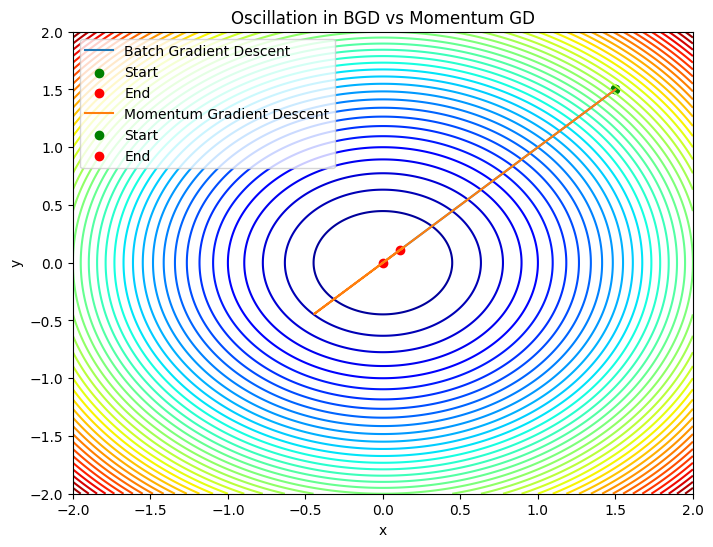

In [74]:
plot_paths(quadratic_loss,[path_bgd,path_momentum],["Batch Gradient Descent","Momentum Gradient Descent"],"Oscillation in BGD vs Momentum GD")

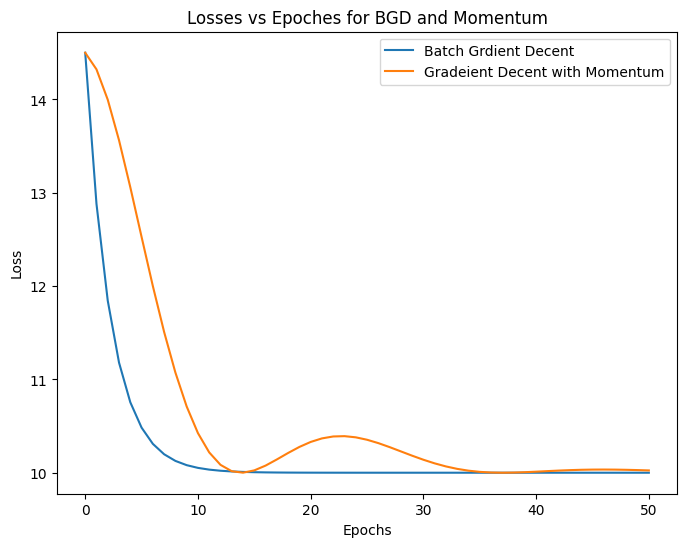

In [75]:
plot_losses([losses_bgd,losses_momentum],["Batch Grdient Decent" , "Gradeient Decent with Momentum"],"Losses vs Epoches for BGD and Momentum")